# Base spectrum analysis

This notebook analyzes the fitted spectral peaks for all runs in `manual_peak_fits_all.csv` whose paths are either

- `data/(date)/(product)/...`, or
- `data/Co57_runs_overnight/...`

using the saved base calibration and the saved day-by-day calibration uncertainty adjustments.

What this notebook does:

1. loads the peak-fit table and calibration tables,
2. filters to the requested base data runs and the overnight Co57 runs,
3. converts fitted ADC quantities to energy using the inferred day and preamp,
4. reconstructs the saved Gaussian + linear-background fits in energy space,
5. summarizes peak energies, widths, amplitudes, and calibration choices by file,
6. gives a dedicated Co57 overnight summary,
7. optionally overlays the reconstructed fit on the raw background-subtracted spectrum if the processed spectra are available locally.

For the ordinary `data/(date)/(product)` runs, the filenames do not explicitly carry a preamp label. In the existing workflow these runs are treated as **preamp 0**, so this notebook follows that same convention. The overnight Co57 file already carries its preamp label explicitly.


In [1]:
# -----------------------------
# IMPORTS
# -----------------------------

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
# -----------------------------
# PATH RESOLUTION
# -----------------------------

def resolve_existing_path(*candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    msg = 'Could not find any of these candidate paths:\n' + '\n'.join(str(c) for c in candidates)
    raise FileNotFoundError(msg)

PEAKS_FILE = resolve_existing_path(
    'peak_analysis_outputs/manual_peak_fits_all.csv',
    'manual_peak_fits_all.csv',
    'manual_peak_fits_all (4).csv',
)

BASE_CAL_FILE = resolve_existing_path(
    'calibration_data/base_calibration_feb24.csv',
    'base_calibration_feb24.csv',
    'base_calibration_feb24 (1).csv',
)

DAILY_ERR_FILE = resolve_existing_path(
    'calibration_data/daily_error_adjustments.csv',
    'daily_error_adjustments.csv',
    'daily_error_adjustments (1).csv',
)

PROCESSED_DATA_ROOT_CANDIDATES = [
    Path('processed_data'),
    Path('.')
]

BACKGROUND_FILE_CANDIDATES = [
    Path('processed_data/calibration/background_550PM_feb26_213PM_mar3.csv'),
    Path('calibration/background_550PM_feb26_213PM_mar3.csv'),
]

print('PEAKS_FILE    =', PEAKS_FILE)
print('BASE_CAL_FILE =', BASE_CAL_FILE)
print('DAILY_ERR_FILE=', DAILY_ERR_FILE)

PEAKS_FILE    = peak_analysis_outputs/manual_peak_fits_all.csv
BASE_CAL_FILE = calibration_data/base_calibration_feb24.csv
DAILY_ERR_FILE= calibration_data/daily_error_adjustments.csv


In [3]:
# -----------------------------
# LOAD TABLES
# -----------------------------

peaks_df = pd.read_csv(PEAKS_FILE)
base_cal_df = pd.read_csv(BASE_CAL_FILE)
daily_err_df = pd.read_csv(DAILY_ERR_FILE)

print("peaks_df shape    :", peaks_df.shape)
print("base_cal_df shape :", base_cal_df.shape)
print("daily_err_df shape:", daily_err_df.shape)

display(base_cal_df)
display(daily_err_df)


peaks_df shape    : (138, 18)
base_cal_df shape : (2, 5)
daily_err_df shape: (6, 9)


,preamp,slope,slope_err,offset,offset_err
0,preamp0,1.317572,0.004624,-3.916731,2.043277
1,preamp100,1.825932,0.019079,-15.747695,13.242461


,day,preamp,n_points,temp_C_mean,mean_abs_resid_keV,rms_resid_keV,mean_formal_err_keV,extra_sigma_keV,redchi2_base_naive
0,feb26,0,2,22.4,9.508222,11.709149,5.641836,10.260306,2.842786
1,mar3,0,3,22.0,9.838862,15.275663,4.849381,14.485489,4.901898
2,mar5,0,3,21.9,6.093704,8.671232,9.366776,0.000000,0.674812
3,feb26,100,2,22.4,0.977128,1.357705,18.751697,0.000000,0.004936
4,mar3,100,2,22.5,6.550454,6.857201,18.712101,0.000000,0.130133
5,mar5,100,2,21.9,5.720025,6.031281,18.718196,0.000000,0.100371


In [4]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------

def normalize_preamp_value(value):
    text = str(value).lower().replace("_", "").replace(" ", "")
    if "100" in text:
        return 100
    if text in {"0", "preamp0"} or "preamp0" in text:
        return 0
    try:
        return int(float(value))
    except Exception:
        return np.nan


def _month_token_to_day(token):
    token = str(token).lower().replace("_", "")
    mapping = {
        "feb24": "feb24",
        "feb26": "feb26",
        "mar3": "mar3",
        "mar5": "mar5",
    }
    return mapping.get(token)


def infer_day_from_relpath(relpath):
    rel = str(relpath).lower().replace("_", "")
    for token in ["feb24", "feb26", "mar3", "mar5"]:
        if token in rel:
            return token
    return None


def extract_preamp_from_path(relpath):
    lower = str(relpath).lower().replace("_", "")

    if "preamp100" in lower:
        return 100
    if "preamp0" in lower:
        return 0

    # Standard data/(date)/(product) source runs are preamp-0 in this workflow.
    if lower.startswith("data/"):
        return 0

    return None


def infer_product_from_path(relpath):
    rel = Path(str(relpath)).as_posix().lower()
    name = Path(rel).name.lower()

    if "co57" in rel:
        return "Co57"
    if "cs137" in rel or name.startswith("cs"):
        return "Cs137"
    if "na22" in rel or name.startswith("na"):
        return "Na22"
    if "co60" in rel or "/co60/" in rel or name.startswith("co_") or name.startswith("co60"):
        return "Co60"
    return "unknown"


def is_requested_run(relpath):
    rel = Path(str(relpath)).as_posix().lower()

    base_pattern = re.match(r"^data/(feb_24|feb_26|mar_3|mar_5)/[^/]+/.+\.csv$", rel) is not None
    overnight_co57 = rel.startswith("data/co57_runs_overnight/") and rel.endswith(".csv")

    return base_pattern or overnight_co57


def gaussian(x, A, mu, sigma):
    sigma = abs(float(sigma))
    sigma = max(sigma, 1e-12)
    return float(A) * np.exp(-((np.asarray(x, dtype=float) - float(mu)) ** 2) / (2 * sigma**2))


def group_model_curve_adc(group_df, npts=1000):
    xmin = float(group_df["fit_xmin"].iloc[0])
    xmax = float(group_df["fit_xmax"].iloc[0])
    bg_m = float(group_df["background_slope"].iloc[0])
    bg_b = float(group_df["background_intercept"].iloc[0])

    x = np.linspace(xmin, xmax, int(npts))
    y_bg = bg_m * x + bg_b
    y_total = y_bg.copy()

    peak_curves = []
    for _, row in group_df.sort_values("peak_in_group").iterrows():
        y_peak = gaussian(x, row["amplitude_counts_per_s"], row["center_ADC"], row["sigma_ADC"])
        y_total = y_total + y_peak
        peak_curves.append({
            "peak_in_group": int(row["peak_in_group"]),
            "x_adc": x.copy(),
            "y_peak": y_peak,
        })

    return {
        "group_id": int(group_df["group_id"].iloc[0]),
        "x_adc": x,
        "y_bg": y_bg,
        "y_total": y_total,
        "peak_curves": peak_curves,
    }


def adc_to_energy(adc, adc_err, relpath):
    adc = np.asarray(adc, dtype=float)
    adc_err = np.asarray(adc_err, dtype=float)

    day = infer_day_from_relpath(relpath)
    preamp = extract_preamp_from_path(relpath)

    if preamp not in BASE_CAL_MAP:
        raise RuntimeError(f"No base calibration found for preamp={preamp} from file: {relpath}")

    row = BASE_CAL_MAP[preamp]
    slope = float(row["slope"])
    slope_err = float(row["slope_err"])
    offset = float(row["offset"])
    offset_err = float(row["offset_err"])

    energy = slope * adc + offset

    extra_sigma = 0.0
    if day is not None and (str(day).lower(), preamp) in DAILY_ERR_MAP:
        extra_sigma = float(DAILY_ERR_MAP[(str(day).lower(), preamp)]["extra_sigma_keV"])

    energy_err = np.sqrt(
        (slope * adc_err) ** 2
        + (adc * slope_err) ** 2
        + offset_err ** 2
        + extra_sigma ** 2
    )

    return energy, energy_err, slope, slope_err, offset, offset_err, extra_sigma, day, preamp


def fwhm_from_sigma(sigma):
    return 2.354820045 * np.asarray(sigma, dtype=float)


base_cal_df["preamp_norm"] = base_cal_df["preamp"].map(normalize_preamp_value)
daily_err_df["preamp_norm"] = daily_err_df["preamp"].map(normalize_preamp_value)

BASE_CAL_MAP = {
    int(row["preamp_norm"]): row
    for _, row in base_cal_df.dropna(subset=["preamp_norm"]).iterrows()
}

DAILY_ERR_MAP = {
    (str(row["day"]).lower(), int(row["preamp_norm"])): row
    for _, row in daily_err_df.dropna(subset=["preamp_norm"]).iterrows()
}

print("BASE_CAL_MAP keys:", sorted(BASE_CAL_MAP))
print("DAILY_ERR_MAP keys:", sorted(DAILY_ERR_MAP))


BASE_CAL_MAP keys: [0, 100]
DAILY_ERR_MAP keys: [('feb26', 0), ('feb26', 100), ('mar3', 0), ('mar3', 100), ('mar5', 0), ('mar5', 100)]


In [5]:
# -----------------------------
# FILTER TO REQUESTED RUNS
# -----------------------------

selected_df = peaks_df.loc[peaks_df["file"].map(is_requested_run)].copy()
selected_df = selected_df.sort_values(["file", "group_id", "peak_in_group"]).reset_index(drop=True)

selected_df["day"] = selected_df["file"].map(infer_day_from_relpath)
selected_df["preamp"] = selected_df["file"].map(extract_preamp_from_path)
selected_df["product"] = selected_df["file"].map(infer_product_from_path)
selected_df["is_overnight_co57"] = selected_df["file"].astype(str).str.contains("Co57_runs_overnight", case=False, na=False)

print("Selected rows :", len(selected_df))
print("Selected files:", selected_df["file"].nunique())

file_summary = (
    selected_df.groupby(["file", "day", "product", "preamp", "is_overnight_co57"], as_index=False)
    .agg(
        n_fitted_peaks=("file", "size"),
        max_amplitude_counts_per_s=("amplitude_counts_per_s", "max"),
        n_labeled_peaks=("theoretical_energy_keV", lambda s: int(s.notna().sum())),
    )
    .sort_values(["is_overnight_co57", "day", "product", "file"])
    .reset_index(drop=True)
)

display(file_summary)


Selected rows : 28
Selected files: 12


,file,day,product,preamp,is_overnight_co57,n_fitted_peaks,max_amplitude_counts_per_s,n_labeled_peaks
0,data/feb_24/co60/Co_22.4C_feb24_run1.csv,feb24,Co60,0,False,2,14.480000,2
1,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,feb24,Na22,0,False,3,15.313691,3
2,data/feb_26/co60/Co_22.8C_feb26_run1.csv,feb26,Co60,0,False,2,14.600645,2
3,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,feb26,Cs137,0,False,2,91.293221,2
4,data/feb_26/na22/Na_22.6C_feb26_run1.csv,feb26,Na22,0,False,3,15.196903,3
5,data/mar_3/co60/Co_22.5C_mar3_run1.csv,mar3,Co60,0,False,2,4.420824,2
6,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,mar3,Cs137,0,False,3,28.712067,3
7,data/mar_3/na22/Na_22.5C_mar3_run1.csv,mar3,Na22,0,False,2,4.245072,2
8,data/mar_5/co60/Co_22.0C_mar5_run1.csv,mar5,Co60,0,False,2,5.957421,2
9,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,mar5,Cs137,0,False,3,38.141283,3


In [6]:
# -----------------------------
# CONVERT ADC FIT RESULTS TO ENERGY
# -----------------------------

selected_df["center_keV"], selected_df["center_keV_err"], selected_df["cal_slope_keV_per_ADC"], selected_df["cal_slope_err"], selected_df["cal_offset_keV"], selected_df["cal_offset_err"], selected_df["cal_extra_sigma_keV"], selected_df["day_check"], selected_df["preamp_check"] = zip(
    *selected_df.apply(
        lambda row: adc_to_energy(row["center_ADC"], row["center_ADC_err"], row["file"]),
        axis=1,
    )
)

selected_df["center_keV"] = selected_df["center_keV"].astype(float)
selected_df["center_keV_err"] = selected_df["center_keV_err"].astype(float)
selected_df["cal_slope_keV_per_ADC"] = selected_df["cal_slope_keV_per_ADC"].astype(float)
selected_df["cal_slope_err"] = selected_df["cal_slope_err"].astype(float)
selected_df["cal_offset_keV"] = selected_df["cal_offset_keV"].astype(float)
selected_df["cal_offset_err"] = selected_df["cal_offset_err"].astype(float)
selected_df["cal_extra_sigma_keV"] = selected_df["cal_extra_sigma_keV"].astype(float)

selected_df["sigma_keV"] = np.abs(selected_df["cal_slope_keV_per_ADC"]) * selected_df["sigma_ADC"].astype(float)
selected_df["sigma_keV_err"] = np.sqrt(
    (selected_df["sigma_ADC"].astype(float) * selected_df["cal_slope_err"].astype(float)) ** 2
    + (np.abs(selected_df["cal_slope_keV_per_ADC"]) * selected_df["sigma_ADC_err"].astype(float)) ** 2
)

selected_df["fwhm_keV"] = fwhm_from_sigma(selected_df["sigma_keV"])
selected_df["fwhm_keV_err"] = fwhm_from_sigma(selected_df["sigma_keV_err"])
selected_df["resolution_percent"] = 100.0 * selected_df["fwhm_keV"] / selected_df["center_keV"]
selected_df["fit_xmin_keV"] = selected_df["cal_slope_keV_per_ADC"] * selected_df["fit_xmin"].astype(float) + selected_df["cal_offset_keV"]
selected_df["fit_xmax_keV"] = selected_df["cal_slope_keV_per_ADC"] * selected_df["fit_xmax"].astype(float) + selected_df["cal_offset_keV"]
selected_df["theoretical_minus_fit_keV"] = selected_df["theoretical_energy_keV"] - selected_df["center_keV"]

cols_to_show = [
    "file", "day", "product", "preamp", "group_id", "peak_in_group",
    "center_ADC", "center_ADC_err", "center_keV", "center_keV_err",
    "sigma_keV", "sigma_keV_err", "fwhm_keV", "resolution_percent",
    "amplitude_counts_per_s", "amplitude_counts_per_s_err",
    "theoretical_energy_keV", "theoretical_energy_keV_err", "theoretical_minus_fit_keV",
    "cal_slope_keV_per_ADC", "cal_offset_keV", "cal_extra_sigma_keV",
]

display(selected_df[cols_to_show])


,file,day,product,preamp,group_id,peak_in_group,center_ADC,center_ADC_err,center_keV,center_keV_err,sigma_keV,sigma_keV_err,fwhm_keV,resolution_percent,amplitude_counts_per_s,amplitude_counts_per_s_err,theoretical_energy_keV,theoretical_energy_keV_err,theoretical_minus_fit_keV,cal_slope_keV_per_ADC,cal_offset_keV,cal_extra_sigma_keV
0,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,None,Co57,0,1,1,9.417134,0.131460,8.491022,2.051068,0.796006,0.399044,1.874451,22.075682,0.015128,0.004874,14.4136,0.000300,5.922578,1.317572,-3.916731,0.000000
1,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,None,Co57,0,2,1,103.611710,0.017590,132.599162,2.098823,5.725738,0.035193,13.483083,10.168302,1.967043,0.007003,122.0600,0.010000,-10.539162,1.317572,-3.916731,0.000000
2,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,feb24,Na22,0,1,1,295.358294,0.042137,385.239101,2.458317,12.863571,0.084090,30.291395,7.863011,15.313691,0.060345,511.0060,NaN,125.766899,1.317572,-3.916731,0.000000
3,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,feb24,Na22,0,2,1,706.462932,0.344484,926.899079,3.879735,21.336751,0.565083,50.244208,5.420677,2.093966,0.039015,1274.5370,0.008000,347.637921,1.317572,-3.916731,0.000000
4,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,feb24,Na22,0,3,1,991.021280,1.612532,1301.825202,5.448707,27.056272,3.008299,63.712651,4.894102,0.108178,0.014106,1785.3630,0.008000,483.537798,1.317572,-3.916731,0.000000
5,data/feb_24/co60/Co_22.4C_feb24_run1.csv,feb24,Co60,0,1,1,650.544541,0.188358,853.222569,3.644921,19.582008,0.334298,46.112104,5.404464,14.480000,0.177279,1173.2280,0.003000,320.005431,1.317572,-3.916731,0.000000
6,data/feb_24/co60/Co_22.4C_feb24_run1.csv,feb24,Co60,0,1,2,736.600890,0.236777,966.608009,3.984164,21.546430,0.382848,50.737965,5.249073,12.164878,0.162301,1332.4940,0.002000,365.885991,1.317572,-3.916731,0.000000
7,data/feb_26/co60/Co_22.8C_feb26_run1.csv,feb26,Co60,0,1,1,650.682642,0.195736,853.404528,10.888897,19.649832,0.353800,46.271819,5.422026,14.600645,0.186950,1173.2280,0.003000,319.823472,1.317572,-3.916731,10.260306
8,data/feb_26/co60/Co_22.8C_feb26_run1.csv,feb26,Co60,0,1,2,736.820726,0.247477,966.897659,11.007423,21.711718,0.420918,51.127190,5.287756,12.268610,0.173446,1332.4940,0.002000,365.596341,1.317572,-3.916731,10.260306
9,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,feb26,Cs137,0,1,1,503.190803,0.186243,659.073403,10.720211,20.386744,0.291892,48.007114,7.284031,91.293221,0.963175,661.6570,0.003000,2.583597,1.317572,-3.916731,10.260306


## Per-file summary

This summary reports, for each run, the strongest fitted peak and the typical fitted peak width after converting into energy space.


In [7]:
# -----------------------------
# PER-FILE SUMMARY TABLE
# -----------------------------

def strongest_peak_table(df):
    idx = df.groupby("file")["amplitude_counts_per_s"].idxmax()
    strongest = df.loc[idx].copy()
    strongest = strongest.rename(columns={
        "center_keV": "strongest_peak_keV",
        "center_keV_err": "strongest_peak_keV_err",
        "amplitude_counts_per_s": "strongest_peak_amplitude_counts_per_s",
        "sigma_keV": "strongest_peak_sigma_keV",
        "fwhm_keV": "strongest_peak_fwhm_keV",
    })
    return strongest[[
        "file", "product", "day", "preamp", "group_id", "peak_in_group",
        "strongest_peak_keV", "strongest_peak_keV_err", "strongest_peak_amplitude_counts_per_s",
        "strongest_peak_sigma_keV", "strongest_peak_fwhm_keV"
    ]]

strongest_df = strongest_peak_table(selected_df)

per_file_summary = (
    selected_df.groupby(["file", "day", "product", "preamp", "cal_slope_keV_per_ADC", "cal_offset_keV", "cal_extra_sigma_keV"], as_index=False)
    .agg(
        n_peaks=("file", "size"),
        mean_peak_energy_keV=("center_keV", "mean"),
        median_peak_energy_keV=("center_keV", "median"),
        mean_sigma_keV=("sigma_keV", "mean"),
        mean_fwhm_keV=("fwhm_keV", "mean"),
        mean_resolution_percent=("resolution_percent", "mean"),
        total_gaussian_area_counts=("gaussian_area_counts", "sum"),
        total_peak_amplitude_counts_per_s=("amplitude_counts_per_s", "sum"),
        n_labeled_peaks=("theoretical_energy_keV", lambda s: int(s.notna().sum())),
    )
    .merge(strongest_df, on=["file", "product", "day", "preamp"], how="left")
    .sort_values(["day", "product", "file"])
    .reset_index(drop=True)
)

display(per_file_summary)


,file,day,product,preamp,cal_slope_keV_per_ADC,cal_offset_keV,cal_extra_sigma_keV,n_peaks,mean_peak_energy_keV,median_peak_energy_keV,mean_sigma_keV,mean_fwhm_keV,mean_resolution_percent,total_gaussian_area_counts,total_peak_amplitude_counts_per_s,n_labeled_peaks,group_id,peak_in_group,strongest_peak_keV,strongest_peak_keV_err,strongest_peak_amplitude_counts_per_s,strongest_peak_sigma_keV,strongest_peak_fwhm_keV
0,data/feb_24/co60/Co_22.4C_feb24_run1.csv,feb24,Co60,0,1.317572,-3.916731,0.000000,2,909.915289,909.915289,20.564219,48.425034,5.326769,1038.091014,26.644879,2,1,1,853.222569,3.644921,14.480000,19.582008,46.112104
1,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,feb24,Na22,0,1.317572,-3.916731,0.000000,3,871.321127,926.899079,20.418864,48.082751,6.059264,465.330464,17.515835,3,1,1,385.239101,2.458317,15.313691,12.863571,30.291395
2,data/feb_26/co60/Co_22.8C_feb26_run1.csv,feb26,Co60,0,1.317572,-3.916731,10.260306,2,910.151093,910.151093,20.680775,48.699504,5.354891,1052.579512,26.869255,2,1,1,853.404528,10.888897,14.600645,19.649832,46.271819
3,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,feb26,Cs137,0,1.317572,-3.916731,10.260306,2,991.762686,991.762686,37.183831,87.561231,8.440806,3598.911625,91.859034,2,1,1,659.073403,10.720211,91.293221,20.386744,48.007114
4,data/feb_26/na22/Na_22.6C_feb26_run1.csv,feb26,Na22,0,1.317572,-3.916731,10.260306,3,870.046648,926.079938,19.353592,45.574226,5.859178,457.121608,17.354971,3,1,1,384.819646,10.550537,15.196903,12.770021,30.071101
5,data/mar_3/co60/Co_22.5C_mar3_run1.csv,mar3,Co60,0,1.317572,-3.916731,14.485489,2,906.213061,906.213061,20.498790,48.270962,5.328941,318.135260,8.193363,2,1,1,850.142880,14.935783,4.420824,19.371294,45.615912
6,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,mar3,Cs137,0,1.317572,-3.916731,14.485489,3,663.394379,661.596694,22.035490,51.889613,15.438649,1108.298587,33.277958,3,2,1,661.596694,14.816128,28.712067,19.512025,45.947309
7,data/mar_3/na22/Na_22.5C_mar3_run1.csv,mar3,Na22,0,1.317572,-3.916731,14.485489,2,653.440308,653.440308,17.084287,40.230422,6.625815,126.774502,4.843797,2,1,1,384.118480,14.692277,4.245072,12.664608,29.822873
8,data/mar_5/co60/Co_22.0C_mar5_run1.csv,mar5,Co60,0,1.317572,-3.916731,0.000000,2,907.402073,907.402073,20.699537,48.743685,5.373093,430.808756,10.993141,2,1,1,851.300302,3.642524,5.957421,19.501001,45.921348
9,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,mar5,Cs137,0,1.317572,-3.916731,0.000000,3,665.135717,661.739715,23.112648,54.426126,16.877789,1491.848484,44.498546,3,2,1,661.739715,3.114267,38.141283,19.702971,46.396951


## Labeled-peak residuals

Where a theoretical line was assigned in the manual fit table, this compares the calibrated fitted energy to that assigned line.


In [8]:
# -----------------------------
# LABELED PEAK RESIDUALS
# -----------------------------

labeled_df = selected_df.dropna(subset=["theoretical_energy_keV"]).copy()

if len(labeled_df) == 0:
    print("No labeled peaks were found in the requested subset.")
else:
    labeled_df["pull_like_residual"] = labeled_df["theoretical_minus_fit_keV"] / labeled_df["center_keV_err"].replace(0, np.nan)

    residual_summary = (
        labeled_df.groupby(["product", "day"], as_index=False)
        .agg(
            n_labeled=("file", "size"),
            mean_abs_residual_keV=("theoretical_minus_fit_keV", lambda s: np.mean(np.abs(s))),
            rms_residual_keV=("theoretical_minus_fit_keV", lambda s: np.sqrt(np.mean(np.square(s)))),
            mean_abs_pull=("pull_like_residual", lambda s: np.nanmean(np.abs(s))),
        )
        .sort_values(["product", "day"])
        .reset_index(drop=True)
    )

    display(labeled_df[[
        "file", "product", "day", "group_id", "peak_in_group",
        "theoretical_energy_keV", "theoretical_energy_keV_err",
        "center_keV", "center_keV_err", "theoretical_minus_fit_keV", "pull_like_residual"
    ]])
    display(residual_summary)


,file,product,day,group_id,peak_in_group,theoretical_energy_keV,theoretical_energy_keV_err,center_keV,center_keV_err,theoretical_minus_fit_keV,pull_like_residual
0,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,Co57,None,1,1,14.4136,0.000300,8.491022,2.051068,5.922578,2.887558
1,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,Co57,None,2,1,122.0600,0.010000,132.599162,2.098823,-10.539162,-5.021462
2,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,Na22,feb24,1,1,511.0060,NaN,385.239101,2.458317,125.766899,51.159753
3,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,Na22,feb24,2,1,1274.5370,0.008000,926.899079,3.879735,347.637921,89.603527
4,data/feb_24/Na22/Na_22.5C_feb24_run1.csv,Na22,feb24,3,1,1785.3630,0.008000,1301.825202,5.448707,483.537798,88.743587
5,data/feb_24/co60/Co_22.4C_feb24_run1.csv,Co60,feb24,1,1,1173.2280,0.003000,853.222569,3.644921,320.005431,87.794883
6,data/feb_24/co60/Co_22.4C_feb24_run1.csv,Co60,feb24,1,2,1332.4940,0.002000,966.608009,3.984164,365.885991,91.835061
7,data/feb_26/co60/Co_22.8C_feb26_run1.csv,Co60,feb26,1,1,1173.2280,0.003000,853.404528,10.888897,319.823472,29.371521
8,data/feb_26/co60/Co_22.8C_feb26_run1.csv,Co60,feb26,1,2,1332.4940,0.002000,966.897659,11.007423,365.596341,33.213618
9,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,Cs137,feb26,1,1,661.6570,0.003000,659.073403,10.720211,2.583597,0.241002


,product,day,n_labeled,mean_abs_residual_keV,rms_residual_keV,mean_abs_pull
0,Co60,feb24,2,342.945711,343.712114,89.814972
1,Co60,feb26,2,342.709907,343.473244,31.292570
2,Co60,mar3,2,346.647939,347.447838,23.138544
3,Co60,mar5,2,345.458927,346.259424,90.545062
4,Cs137,feb26,2,1.860782,1.996239,0.132745
5,Cs137,mar3,3,9.779287,15.617603,0.568610
6,Cs137,mar5,3,8.093092,12.064756,1.097749
7,Na22,feb24,3,318.980873,351.415347,76.502289
8,Na22,feb26,3,320.255352,352.921399,28.664062
9,Na22,mar3,2,239.331192,264.429572,16.049501


## Overnight Co57 summary

This isolates the overnight Co57 run and reports the dominant converted peaks.


In [9]:
# -----------------------------
# OVERNIGHT Co57 SUMMARY
# -----------------------------

co57_df = selected_df.loc[selected_df["is_overnight_co57"]].copy()

if len(co57_df) == 0:
    print("No overnight Co57 rows found.")
else:
    co57_df = co57_df.sort_values("amplitude_counts_per_s", ascending=False).reset_index(drop=True)
    display(co57_df[[
        "file", "group_id", "peak_in_group", "center_keV", "center_keV_err",
        "sigma_keV", "fwhm_keV", "resolution_percent",
        "amplitude_counts_per_s", "amplitude_counts_per_s_err", "gaussian_area_counts"
    ]])

    print("Strongest overnight Co57 peak:")
    strongest = co57_df.iloc[0]
    print(f"Energy = {strongest['center_keV']:.3f} ± {strongest['center_keV_err']:.3f} keV")
    print(f"Amplitude = {strongest['amplitude_counts_per_s']:.3f} ± {strongest['amplitude_counts_per_s_err']:.3f} counts/s")


,file,group_id,peak_in_group,center_keV,center_keV_err,sigma_keV,fwhm_keV,resolution_percent,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts
0,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,2,1,132.599162,2.098823,5.725738,13.483083,10.168302,1.967043,0.007003,21.426975
1,data/Co57_runs_overnight/Co57_22.2C_preamp0_fe...,1,1,8.491022,2.051068,0.796006,1.874451,22.075682,0.015128,0.004874,0.022910


Strongest overnight Co57 peak:
Energy = 132.599 ± 2.099 keV
Amplitude = 1.967 ± 0.007 counts/s


## Reconstructed fit plots in energy space

Each panel shows the saved Gaussian fit components and the total Gaussian-plus-background model in keV.


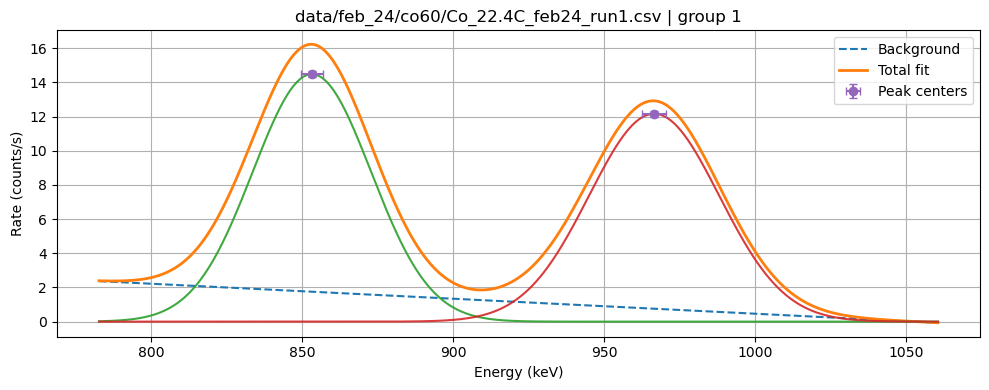

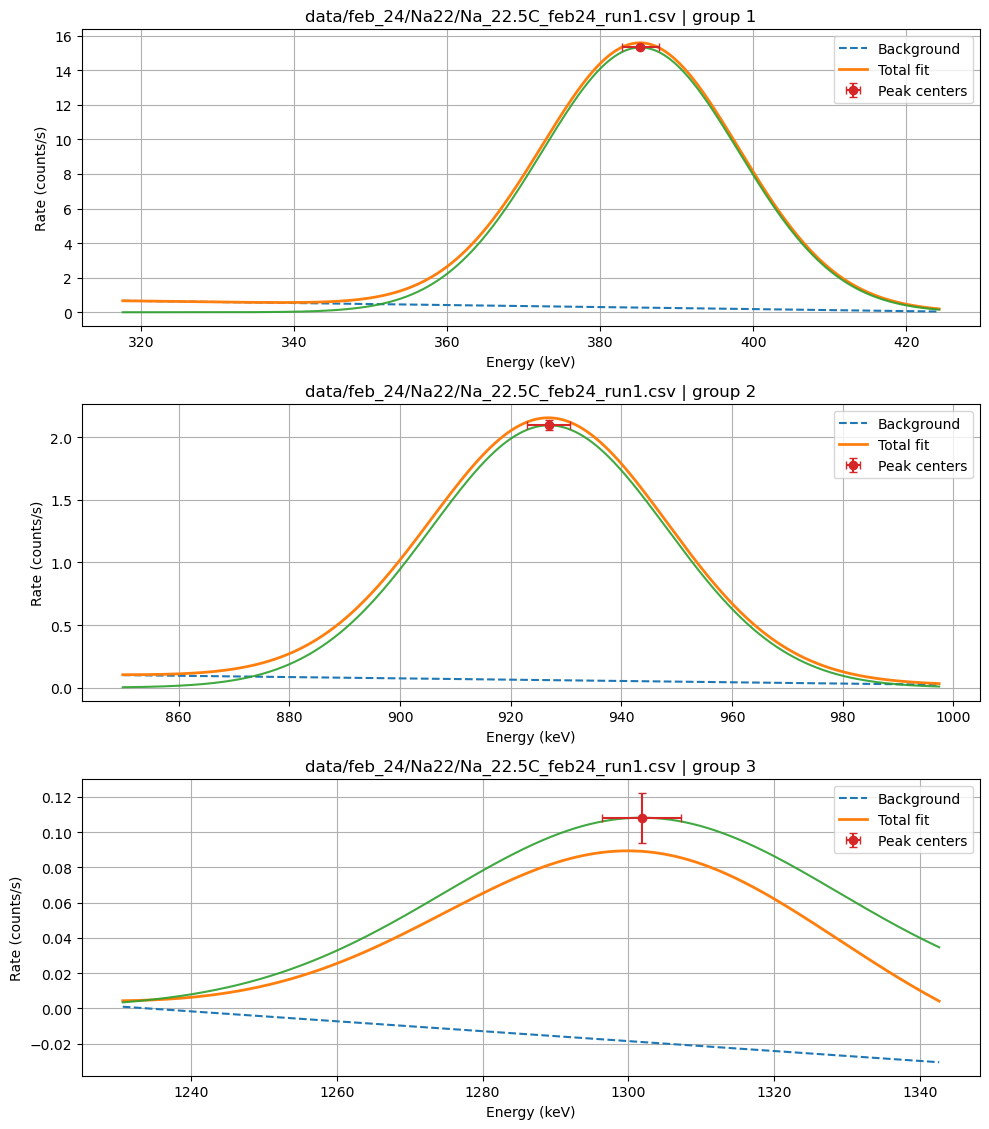

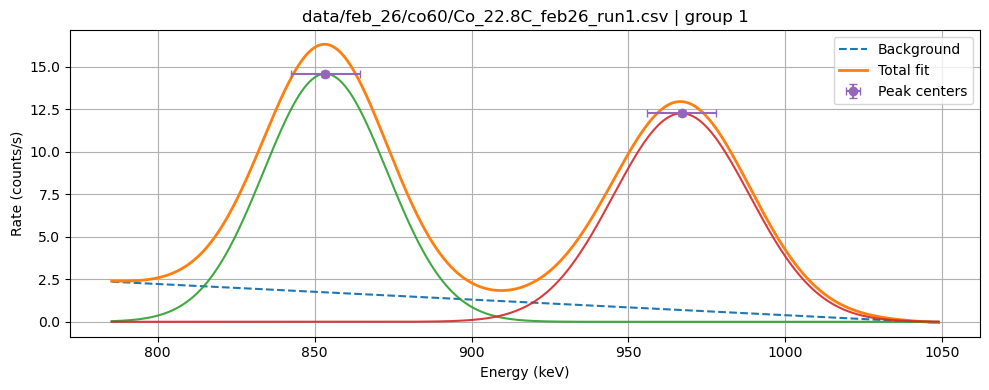

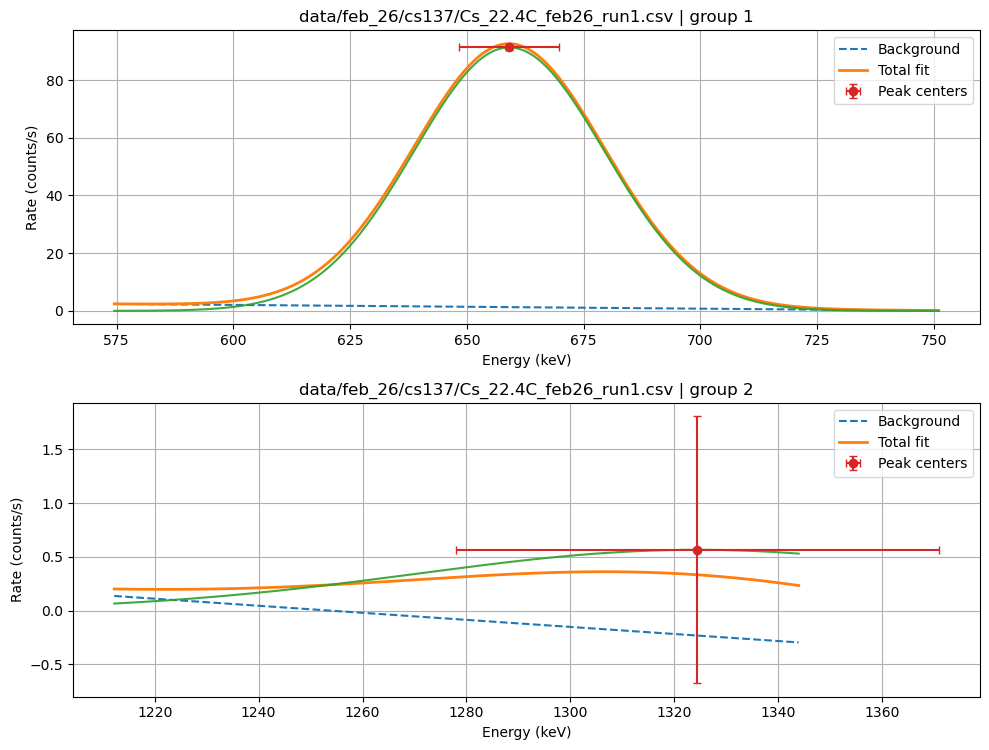

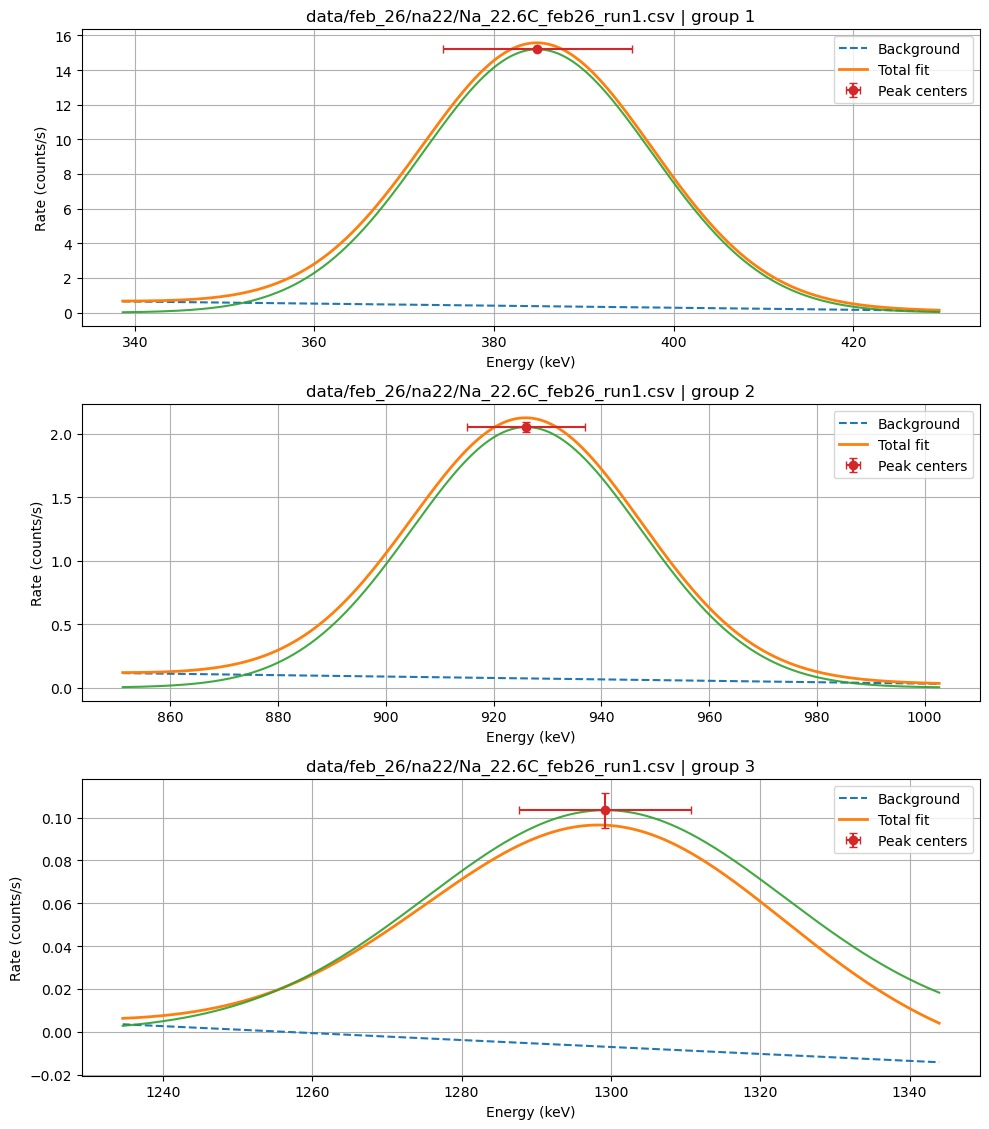

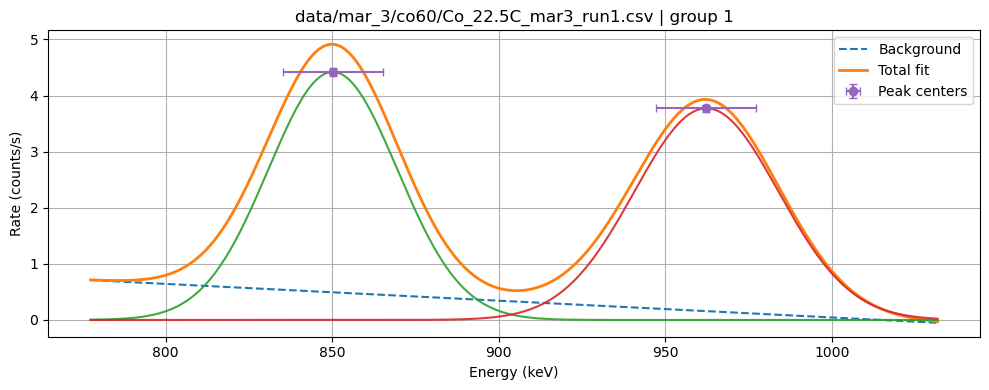

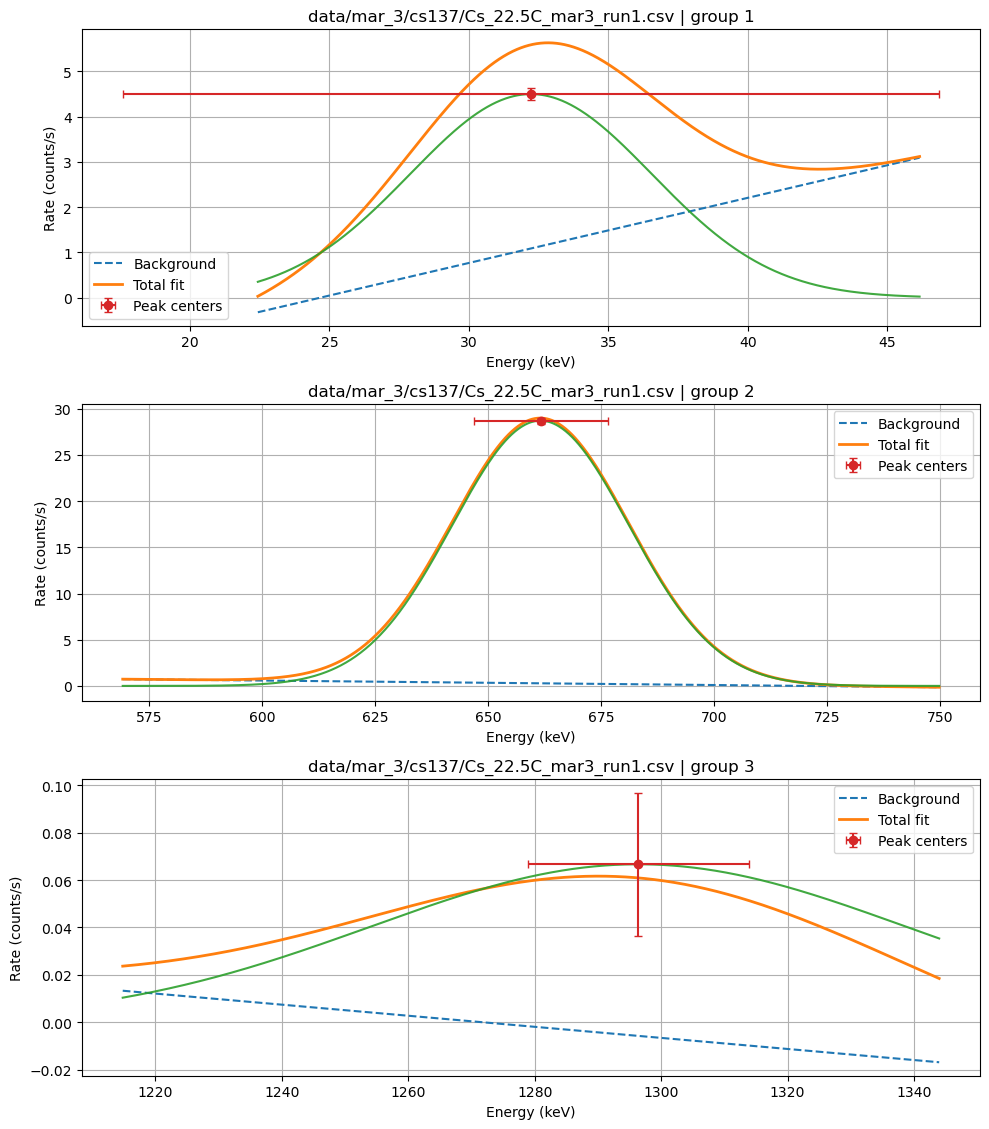

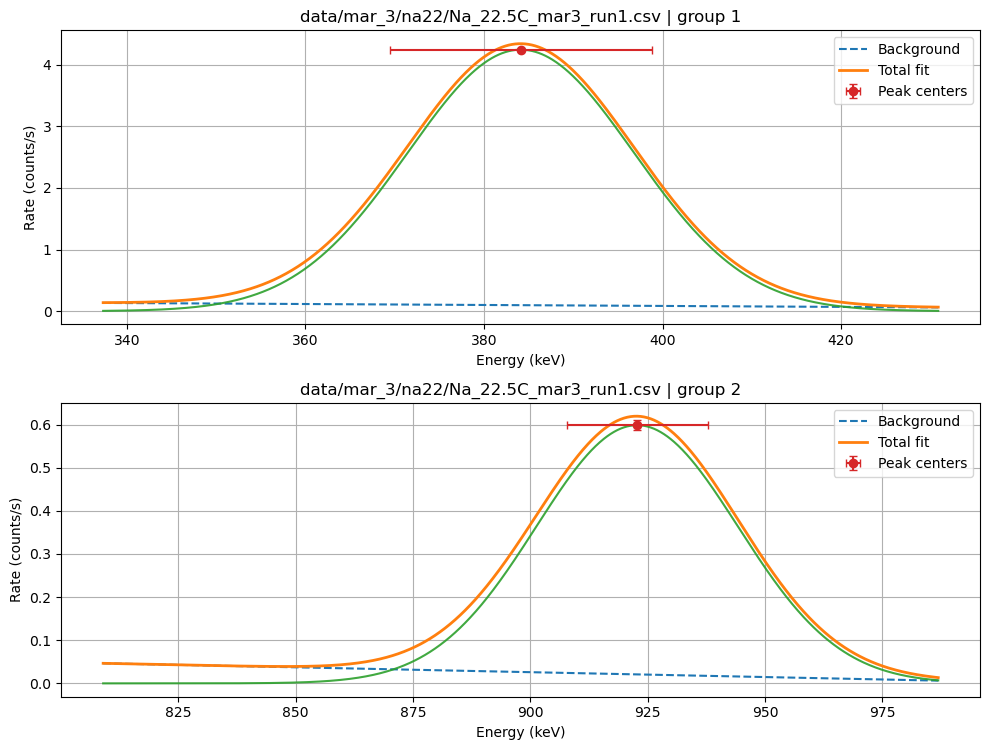

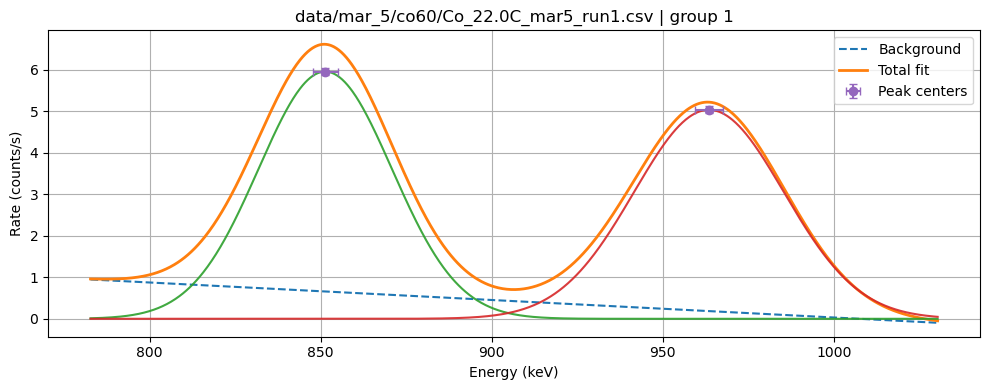

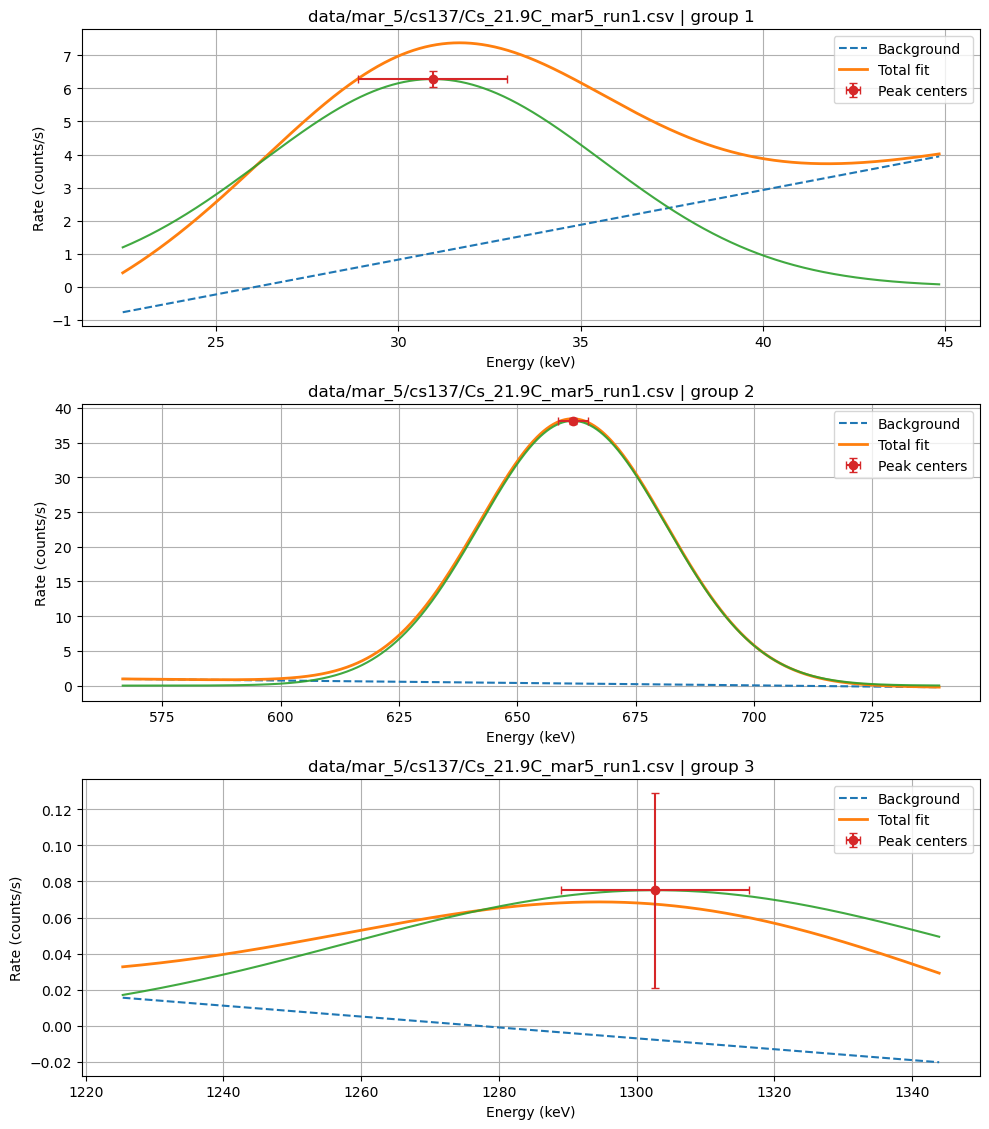

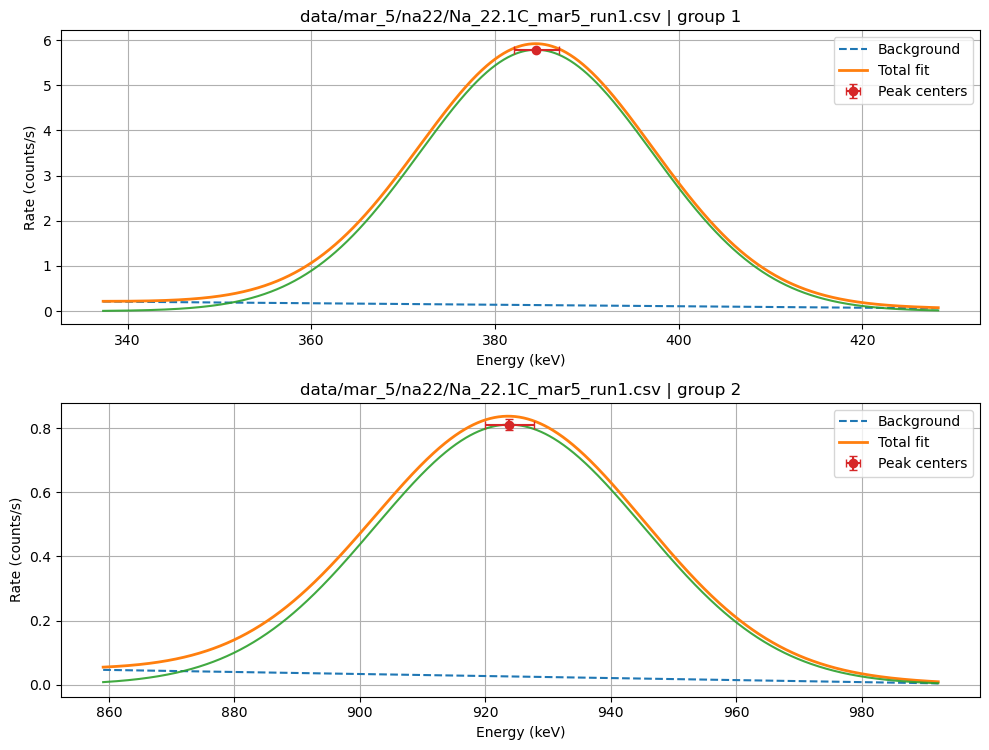

In [10]:
# -----------------------------
# RECONSTRUCT FITS IN ENERGY SPACE
# -----------------------------

PLOT_FILES = per_file_summary["file"].tolist()   # edit this list if you want only a subset
NPTS_PER_GROUP = 1000

for target_file in PLOT_FILES:
    run_df = selected_df.loc[selected_df["file"] == target_file].copy()
    if len(run_df) == 0:
        continue

    run_df = run_df.sort_values(["group_id", "peak_in_group"]).reset_index(drop=True)
    n_groups = run_df["group_id"].nunique()

    fig, axes = plt.subplots(n_groups, 1, figsize=(10, max(4, 3.8 * n_groups)), squeeze=False)
    axes = axes.ravel()

    for ax, (group_id, group_df) in zip(axes, run_df.groupby("group_id")):
        model = group_model_curve_adc(group_df, npts=NPTS_PER_GROUP)
        slope = float(group_df["cal_slope_keV_per_ADC"].iloc[0])
        offset = float(group_df["cal_offset_keV"].iloc[0])

        x_keV = slope * model["x_adc"] + offset
        ax.plot(x_keV, model["y_bg"], linestyle="--", label="Background")
        ax.plot(x_keV, model["y_total"], linewidth=2, label="Total fit")

        for peak_curve in model["peak_curves"]:
            x_peak_keV = slope * peak_curve["x_adc"] + offset
            ax.plot(x_peak_keV, peak_curve["y_peak"], alpha=0.9)

        ax.errorbar(
            group_df["center_keV"],
            group_df["amplitude_counts_per_s"],
            xerr=group_df["center_keV_err"],
            yerr=group_df["amplitude_counts_per_s_err"],
            fmt="o",
            capsize=3,
            label="Peak centers",
        )

        ax.set_xlabel("Energy (keV)")
        ax.set_ylabel("Rate (counts/s)")
        ax.set_title(f"{target_file} | group {group_id}")
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()


## Aggregate energy-centroid plot

This gives a compact visual comparison of the fitted peak energies across all requested runs.


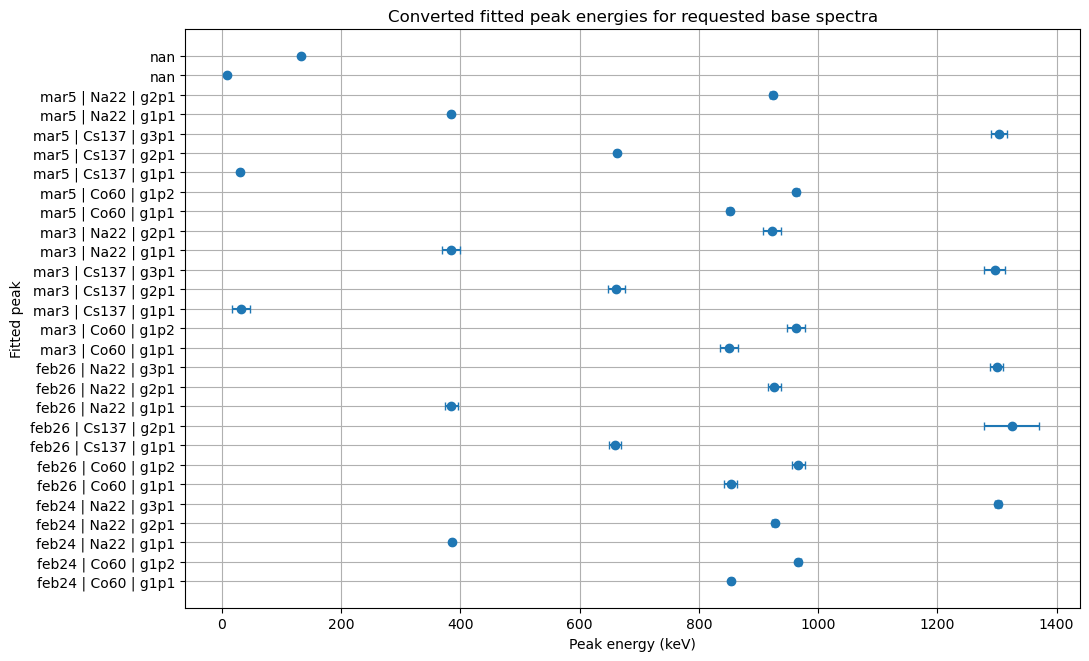

In [11]:
# -----------------------------
# AGGREGATE PEAK-CENTROID PLOT
# -----------------------------

plot_df = selected_df.sort_values(["day", "product", "center_keV"]).reset_index(drop=True).copy()
plot_df["ypos"] = np.arange(len(plot_df))
plot_df["label"] = plot_df["day"] + " | " + plot_df["product"] + " | g" + plot_df["group_id"].astype(str) + "p" + plot_df["peak_in_group"].astype(str)

plt.figure(figsize=(11, max(6, 0.24 * len(plot_df))))
plt.errorbar(
    plot_df["center_keV"],
    plot_df["ypos"],
    xerr=plot_df["center_keV_err"],
    fmt="o",
    capsize=3,
)
plt.yticks(plot_df["ypos"], plot_df["label"])
plt.xlabel("Peak energy (keV)")
plt.ylabel("Fitted peak")
plt.title("Converted fitted peak energies for requested base spectra")
plt.tight_layout()
plt.show()


## Optional raw-spectrum overlay

If the processed spectra are available on disk, the next cell overlays the raw background-subtracted spectrum with the reconstructed fit in energy space. If those files are not available, the cell skips cleanly.


Using background file: processed_data/calibration/background_550PM_feb26_213PM_mar3.csv


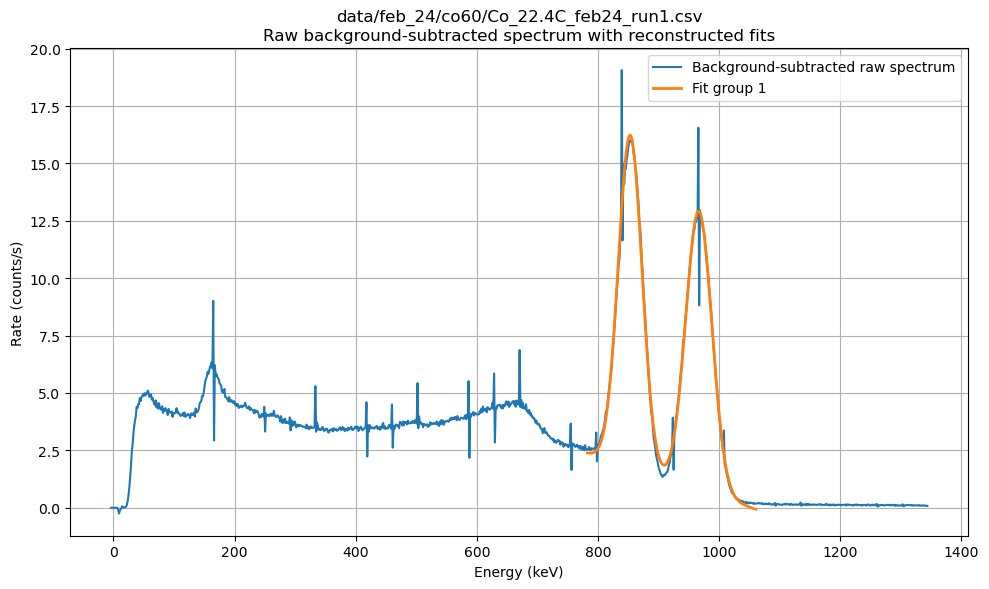

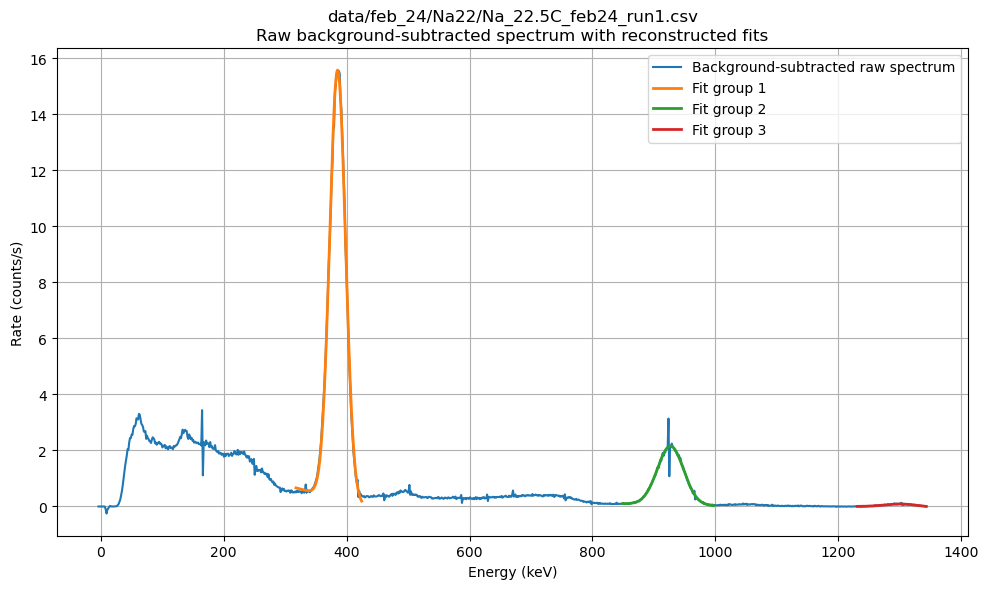

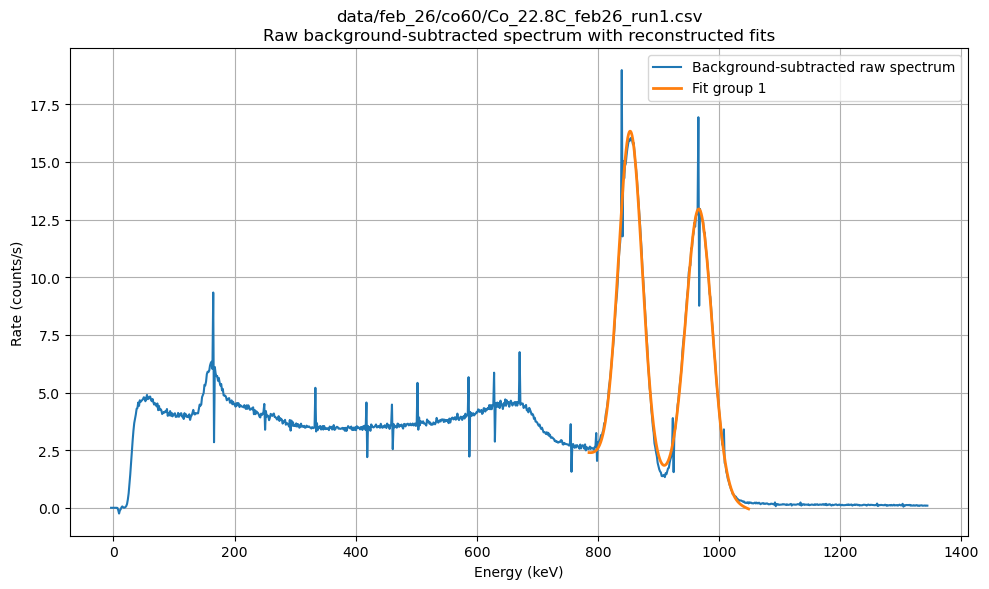

In [12]:
# -----------------------------
# OPTIONAL RAW-SPECTRUM OVERLAY
# -----------------------------

def _extract_first_number(text):
    if text is None:
        return None
    match = re.search(r"[-+]?\d*\.?\d+", str(text))
    if match is None:
        return None
    try:
        return float(match.group())
    except ValueError:
        return None


def resolve_processed_file(relpath):
    relpath = Path(str(relpath))
    for root in PROCESSED_DATA_ROOT_CANDIDATES:
        candidate = root / relpath
        if candidate.exists():
            return candidate
    return None


def resolve_background_file():
    for p in BACKGROUND_FILE_CANDIDATES:
        if p.exists():
            return p
    return None


def load_spectrum(csv_path):
    csv_path = Path(csv_path)
    with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    metadata = {}
    data_start_idx = None

    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped == "Channel Data:":
            data_start_idx = i + 1
            break

        if stripped.startswith("Elapsed Real Time:"):
            parts = stripped.split(",", 1)
            metadata["Elapsed Real Time"] = parts[1].strip() if len(parts) > 1 else ""
            continue

        if "Elapsed Real Time:" in stripped:
            value = stripped.split("Elapsed Real Time:", 1)[1]
            value = value.split(",", 1)[1].strip() if "," in value else value.strip()
            metadata["Elapsed Real Time"] = value
            continue

        if stripped.startswith("Start Time:"):
            metadata["Start Time"] = stripped.split("Start Time:", 1)[1].lstrip(",").strip()
            continue

        if stripped.startswith("End Time:"):
            metadata["End Time"] = stripped.split("End Time:", 1)[1].lstrip(",").strip()
            continue

        if "," in stripped:
            left, right = stripped.split(",", 1)
            left = left.strip().rstrip(":")
            right = right.strip()
            if left and right and left not in metadata:
                metadata[left] = right

    if data_start_idx is None:
        raise RuntimeError(f"Could not locate 'Channel Data:' block in {csv_path}")

    df = pd.read_csv(
        csv_path,
        skiprows=data_start_idx,
        header=None,
        names=["channel", "energy", "counts"],
    )

    df = df.dropna(subset=["channel", "counts"])
    x = pd.to_numeric(df["channel"], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df["counts"], errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ert = metadata.get("Elapsed Real Time", metadata.get("Elapsed Real Time (s)", None))
    metadata["Elapsed Real Time (s)"] = _extract_first_number(ert)
    return x, y, metadata


def counts_to_rate(counts, live_time_s):
    counts = np.asarray(counts, dtype=float)
    if live_time_s is None or not np.isfinite(live_time_s) or live_time_s <= 0:
        raise RuntimeError("Invalid elapsed real time; cannot convert counts to count rate.")
    return counts / float(live_time_s)


def compute_background_subtracted_rate(sample_path, background_path):
    x_sample, counts_sample, meta_sample = load_spectrum(sample_path)
    x_bg, counts_bg, meta_bg = load_spectrum(background_path)

    if len(x_sample) != len(x_bg) or not np.allclose(x_sample, x_bg):
        raise RuntimeError("Sample and background channel grids do not match.")

    raw_rate = counts_to_rate(counts_sample, meta_sample["Elapsed Real Time (s)"])
    bg_rate = counts_to_rate(counts_bg, meta_bg["Elapsed Real Time (s)"])
    return x_sample, raw_rate - bg_rate, meta_sample


RAW_OVERLAY_FILES = per_file_summary["file"].tolist()[:3]   # edit as desired
background_file = resolve_background_file()

if background_file is None:
    print("Background file was not found locally; skipping raw-spectrum overlay.")
else:
    print("Using background file:", background_file)

    for relpath in RAW_OVERLAY_FILES:
        sample_file = resolve_processed_file(relpath)
        if sample_file is None:
            print(f"Skipping {relpath}: processed spectrum not found locally.")
            continue

        run_df = selected_df.loc[selected_df["file"] == relpath].copy().sort_values(["group_id", "peak_in_group"])
        x_adc, y_rate, meta = compute_background_subtracted_rate(sample_file, background_file)
        x_keV, _, slope, _, offset, _, _, _, _ = adc_to_energy(x_adc, np.zeros_like(x_adc), relpath)

        plt.figure(figsize=(10, 6))
        plt.plot(x_keV, y_rate, label="Background-subtracted raw spectrum")

        for group_id, group_df in run_df.groupby("group_id"):
            model = group_model_curve_adc(group_df)
            x_model_keV = slope * model["x_adc"] + offset
            plt.plot(x_model_keV, model["y_total"], linewidth=2, label=f"Fit group {group_id}")

        plt.xlabel("Energy (keV)")
        plt.ylabel("Rate (counts/s)")
        plt.title(f"{relpath}\nRaw background-subtracted spectrum with reconstructed fits")
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()


In [13]:
# -----------------------------
# SAVE OUTPUT TABLES
# -----------------------------

OUTPUT_DIR = Path("base_spectrum_analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

converted_csv = OUTPUT_DIR / "base_spectrum_converted_peaks.csv"
summary_csv = OUTPUT_DIR / "base_spectrum_per_file_summary.csv"
co57_csv = OUTPUT_DIR / "overnight_co57_converted_peaks.csv"

selected_df.to_csv(converted_csv, index=False)
per_file_summary.to_csv(summary_csv, index=False)
co57_df.to_csv(co57_csv, index=False)

print("Saved:")
print(" -", converted_csv)
print(" -", summary_csv)
print(" -", co57_csv)


Saved:
 - base_spectrum_analysis_outputs/base_spectrum_converted_peaks.csv
 - base_spectrum_analysis_outputs/base_spectrum_per_file_summary.csv
 - base_spectrum_analysis_outputs/overnight_co57_converted_peaks.csv
